In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

x,_ = make_blobs(
    n_samples= 300,
    centers= 3,
    cluster_std= 1.2,
    random_state= 42
)

print(x.shape)
print(x[:5])

(300, 2)
[[-7.43086027 -7.89992284]
 [-7.91212323 -7.34157625]
 [-1.52214373  7.54927375]
 [ 4.37866139  3.29170191]
 [-9.32537663 -8.08981317]]


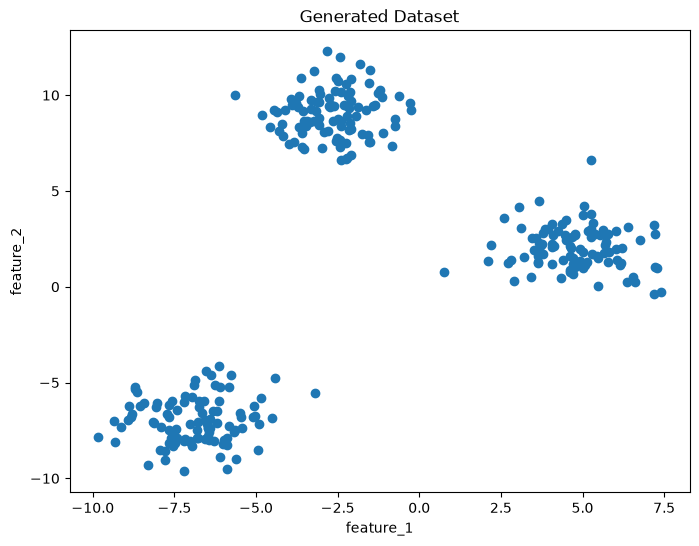

In [2]:
plt.figure(figsize=(8, 6))

plt.scatter(
    x[:, 0],
    x[:, 1]
)

plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Generated Dataset")

plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

print(x_scaled[:5])

[[-1.17808295 -1.38679069]
 [-1.2751755  -1.30311925]
 [ 0.01397294  0.92836   ]
 [ 1.20443274  0.29033844]
 [-1.56029275 -1.41524685]]


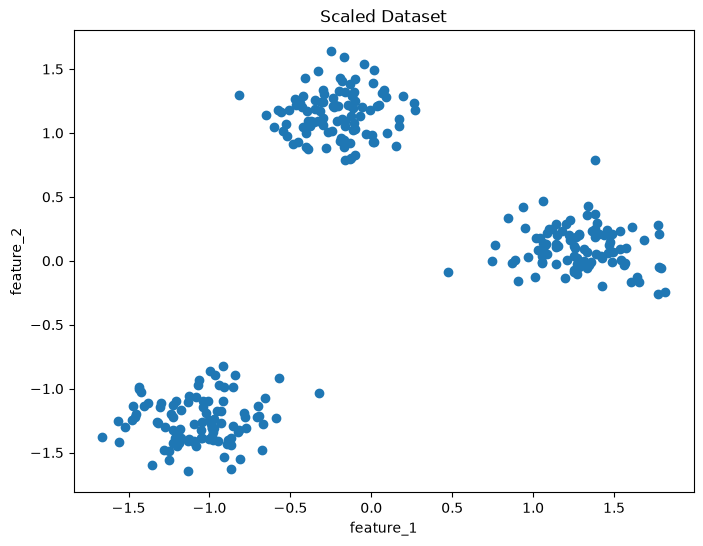

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1]
)

plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Scaled Dataset")

plt.show()

In [14]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(x_scaled)

,"n_components n_components: int, default=1The number of mixture components.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [15]:
labels = gmm.predict(x_scaled)

print(labels[:20])

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0]


In [17]:
print("Means:")
print(gmm.means_)

print("\nWeights:")
print(gmm.weights_)

print("\nCovariances:")
print(gmm.covariances_)

Means:
[[-0.21518875  1.15316649]
 [-1.06790185 -1.25264527]
 [ 1.2830906   0.09947878]]

Weights:
[0.33333333 0.33333333 0.33333333]

Covariances:
[[[ 0.04388145  0.00190179]
  [ 0.00190179  0.03192319]]

 [[ 0.06034654  0.00416807]
  [ 0.00416807  0.03178156]]

 [[ 0.06273297 -0.00428572]
  [-0.00428572  0.02748911]]]


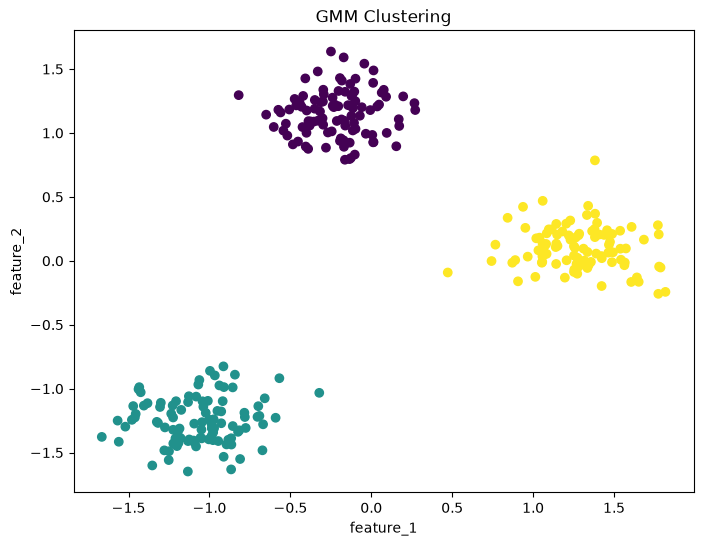

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1],
    c=labels
)

plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("GMM Clustering")

plt.show()

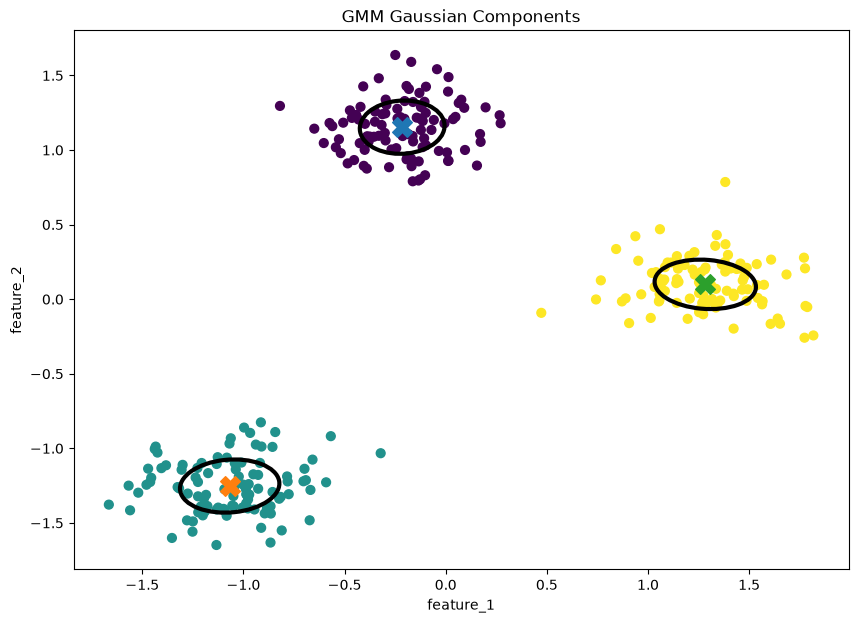

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.figure(figsize=(10, 7))

# Plot data
plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1],
    c=labels,
    s=40
)

# Plot Gaussian ellipses
for i in range(gmm.n_components):

    mean = gmm.means_[i]
    cov = gmm.covariances_[i]

    # Eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort eigenvalues
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Angle of ellipse
    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        )
    )

    # Width and height
    width = 2 * np.sqrt(eigenvalues[0])
    height = 2 * np.sqrt(eigenvalues[1])

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        linewidth=3
    )

    plt.gca().add_patch(ellipse)

    # Mark mean
    plt.scatter(
        mean[0],
        mean[1],
        marker='X',
        s=200
    )

plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("GMM Gaussian Components")

plt.show()

In [19]:
probabilities = gmm.predict_proba(x_scaled)

print("First 10 probability predictions:")
print(probabilities[:10])

print("\nShape:")
print(probabilities.shape)

First 10 probability predictions:
[[1.17382982e-47 1.00000000e+00 2.27113543e-43]
 [1.11947241e-45 1.00000000e+00 4.64220225e-43]
 [1.00000000e+00 5.86508643e-35 4.15909052e-10]
 [3.46446455e-16 2.79767684e-32 1.00000000e+00]
 [1.35059150e-51 1.00000000e+00 5.07293241e-51]
 [9.72313852e-24 1.06259817e-32 1.00000000e+00]
 [1.00000000e+00 9.88012628e-44 4.50976698e-16]
 [3.95773114e-23 8.49446972e-30 1.00000000e+00]
 [1.00000000e+00 8.64164473e-40 5.60004292e-16]
 [1.00000000e+00 5.94328180e-44 9.25625378e-20]]

Shape:
(300, 3)


K=1 | AIC=1658.59 | BIC=1677.11
K=2 | AIC=792.34 | BIC=833.08
K=3 | AIC=474.63 | BIC=537.60
K=4 | AIC=480.55 | BIC=565.73
K=5 | AIC=485.94 | BIC=593.35
K=6 | AIC=494.85 | BIC=624.49

Best AIC: 3
Best BIC: 3


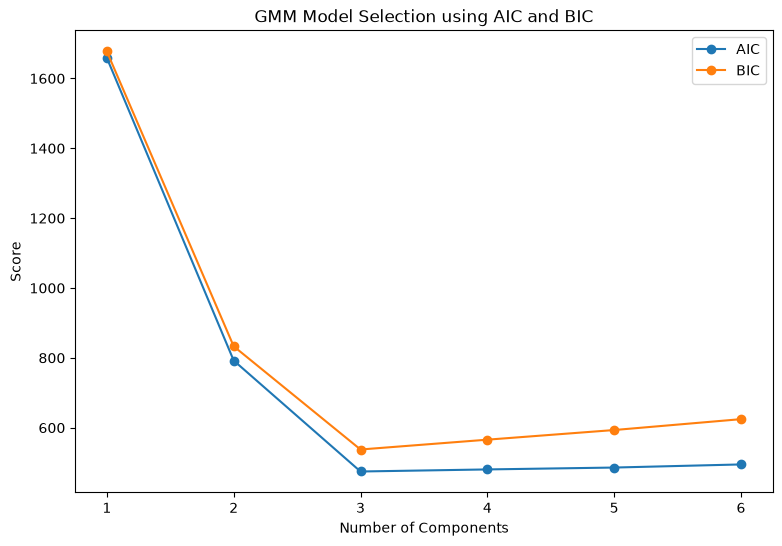

In [20]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

components = range(1, 7)

aic_scores = []
bic_scores = []

for k in components:

    model = GaussianMixture(
        n_components=k,
        random_state=42
    )

    model.fit(x_scaled)

    aic_scores.append(model.aic(x_scaled))
    bic_scores.append(model.bic(x_scaled))


# Print results
for k, aic, bic in zip(components, aic_scores, bic_scores):
    print(f"K={k} | AIC={aic:.2f} | BIC={bic:.2f}")


# Find best models
best_aic = components[aic_scores.index(min(aic_scores))]
best_bic = components[bic_scores.index(min(bic_scores))]

print("\nBest AIC:", best_aic)
print("Best BIC:", best_bic)


# Visualization
plt.figure(figsize=(9, 6))

plt.plot(
    components,
    aic_scores,
    marker='o',
    label='AIC'
)

plt.plot(
    components,
    bic_scores,
    marker='o',
    label='BIC'
)

plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM Model Selection using AIC and BIC")
plt.xticks(list(components))
plt.legend()
plt.show()

# Gaussian Mixture Model (GMM)

## 1. What is GMM?

**Gaussian Mixture Model (GMM)** is an unsupervised machine learning algorithm used for **clustering**.

Unlike K-Means, which assigns each data point to exactly one cluster, GMM assigns a **probability of belonging to each cluster**.

GMM assumes that the data is generated from a mixture of multiple **Gaussian (normal) distributions**.

### Basic idea

```text
                    Dataset
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
      Gaussian 1   Gaussian 2   Gaussian 3
          │            │            │
          └────────────┼────────────┘
                       ↓
                  GMM Model
```

Each Gaussian represents one possible cluster.

---

# 2. Why use GMM?

K-Means mainly asks:

```text
Which centroid is closest?
```

GMM asks:

```text
Which Gaussian is most likely to have generated this point?
```

Therefore, GMM can model:

* Cluster center
* Cluster spread
* Cluster orientation
* Cluster importance
* Probability of cluster membership

---

# 3. Gaussian Distribution

A Gaussian distribution is commonly represented by a bell-shaped curve.

```text
                  ▲
                  │
                ╭─┴─╮
              ╭─╯   ╰─╮
            ╭─╯       ╰─╮
───────────╯─────────────╰──────────→ x
                  μ
                Mean
```

For 2D data, the Gaussian can look like an ellipse.

```text
              __________
           .-'          '-.
         .'       μ        '.
        /                    \
        \                    /
         '.                .'
           '-.__________.-'
```

The shape of this ellipse is determined by the **covariance**.

---

# 4. Important Components of GMM

A GMM mainly learns three things:

```text
GMM
 │
 ├── Means
 │
 ├── Covariances
 │
 └── Weights
```

---

## 4.1 Mean

The **mean** represents the center of a Gaussian component.

For example:

```text
Mean = [-0.21, 1.15]
```

Conceptually:

```text
             Gaussian
          .------------.
        .'              '.
       /        X         \
      |       Mean         |
       \                  /
        '.              .'
          '------------'
```

The `X` represents the center of the cluster.

In scikit-learn:

```python
gmm.means_
```

---

# 5. Covariance

Covariance describes the **spread and orientation** of a Gaussian.

It tells GMM how the points are distributed around the mean.

For example:

```text
Small covariance:

       ╭────╮
       │  X │
       ╰────╯


Large covariance:

    ╭────────────╮
    │      X     │
    ╰────────────╯
```

Covariance can also describe rotated distributions:

```text
       ╱
      ╱
     ╱
    X
   ╱
  ╱
```

In scikit-learn:

```python
gmm.covariances_
```

---

# 6. Weights

The **weight** represents the proportion or importance of each Gaussian component.

For example:

```text
Weights:

Cluster 1 → 0.50
Cluster 2 → 0.30
Cluster 3 → 0.20
```

This means the model estimates that approximately:

```text
50% → Component 1
30% → Component 2
20% → Component 3
```

In scikit-learn:

```python
gmm.weights_
```

The weights should sum approximately to:

```text
1.0
```

---

# 7. Number of Components

The `n_components` parameter specifies how many Gaussian distributions the model should use.

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)
```

Here:

```text
n_components = 3
```

means:

```text
Gaussian 1
Gaussian 2
Gaussian 3
```

---

# 8. Training a GMM

```python
gmm.fit(x_scaled)
```

During training, GMM estimates:

```text
Means
Covariances
Weights
```

for the Gaussian components.

---

# 9. Predicting Clusters

```python
labels = gmm.predict(x_scaled)
```

This gives one cluster label for every data point.

Example:

```text
[1, 1, 2, 0, 1, 0, 2, ...]
```

The labels are simply identifiers:

```text
0 → Gaussian component 0
1 → Gaussian component 1
2 → Gaussian component 2
```

The numerical values themselves do **not** indicate ranking.

---

# 10. Soft Clustering

This is one of the most important concepts in GMM.

GMM performs **soft clustering**.

Instead of simply saying:

```text
Point → Cluster 1
```

GMM can say:

```text
Cluster 0 → 10%
Cluster 1 → 80%
Cluster 2 → 10%
```

This is called **probabilistic cluster assignment**.

---

# 11. `predict_proba()`

We can obtain these probabilities using:

```python
probabilities = gmm.predict_proba(x_scaled)
```

For example:

```text
[0.10, 0.80, 0.10]
```

means:

```text
Component 0 → 10%
Component 1 → 80%
Component 2 → 10%
```

The probabilities for each point sum to approximately:

```text
1.0
```

For our dataset:

```text
Shape:
(300, 3)
```

means:

```text
300 data points
3 probability values per point
```

---

# 12. Hard vs Soft Clustering

### K-Means

```text
Point
  │
  ↓
Closest centroid
  │
  ↓
Cluster 1
```

One point gets one cluster.

### GMM

```text
                 Point
                   │
          ┌────────┼────────┐
          ↓        ↓        ↓
       G1: 10%  G2: 80%  G3: 10%
          └────────┼────────┘
                   ↓
              Mostly G2
```

Therefore:

| K-Means                | GMM                             |
| ---------------------- | ------------------------------- |
| Hard clustering        | Soft clustering                 |
| One cluster assignment | Probability for every component |
| Distance-based         | Probability-based               |

---

# 13. Why GMM Is Different from K-Means

Both algorithms can appear similar because both ultimately identify a "best" cluster.

However, the information they use is different.

### K-Means

```text
Point
  ↓
Distance to centroid
  ↓
Smallest distance
  ↓
Cluster
```

### GMM

```text
Point
  ↓
Mean
+ Covariance
+ Weight
  ↓
Probability under each Gaussian
  ↓
Most likely component
```

Therefore:

> **K-Means mainly uses distance to centroids, whereas GMM uses the probability of a point under each Gaussian, considering its mean, covariance, and weight.**

---

# 14. GMM Can Model Different Cluster Shapes

K-Means works best when clusters are relatively compact and spherical.

GMM can model more flexible distributions because it uses covariance.

```text
K-Means idea:

      ●●●
    ●●●●●
    ●●●●●
      ●●●

       X
```

GMM can represent:

```text
        ╱────────╲
      ╱            ╲
     │      X       │
      ╲            ╱
        ╲────────╱
```

and rotated distributions:

```text
        ╱
       ╱
      ╱
     X
    ╱
   ╱
```

---

# 15. Gaussian Components Visualization

We can visualize the learned Gaussian components using ellipses.

Each ellipse represents approximately:

```text
Mean       → Center
Covariance → Shape/spread
Weight     → Importance
```

Conceptually:

```text
        Gaussian 1

          ________
       .-'        '-.
      /      X       \
      \              /
       '-.________.-'


        Gaussian 2

      ______________
    .'       X        '.
    '.___          ___.'
```

---

# 16. Choosing Number of Components

A major practical question is:

> **How many Gaussian components should we use?**

We can test different values:

```python
n_components = 1
n_components = 2
n_components = 3
n_components = 4
...
```

Two useful model-selection metrics are:

* **AIC**
* **BIC**

---

# 17. AIC — Akaike Information Criterion

AIC balances:

```text
Model fit
+
Model complexity
```

General rule:

> **Lower AIC is better.**

We tested:

```text
K=1 → 1658.59
K=2 → 792.34
K=3 → 474.63  ← lowest
K=4 → 480.55
K=5 → 485.94
K=6 → 494.85
```

Therefore:

```text
Best AIC = 3
```

---

# 18. BIC — Bayesian Information Criterion

BIC also balances model fit and complexity, with a stronger complexity penalty than AIC.

General rule:

> **Lower BIC is better.**

Our results:

```text
K=1 → 1677.11
K=2 → 833.08
K=3 → 537.60  ← lowest
K=4 → 565.73
K=5 → 593.35
K=6 → 624.49
```

Therefore:

```text
Best BIC = 3
```

So both AIC and BIC supported:

```text
n_components = 3
```

---

# 19. GMM Training Concept — EM Algorithm

GMM is commonly trained using the **Expectation-Maximization (EM)** algorithm.

The high-level process is:

```text
Initialize Gaussian parameters
          ↓
Expectation (E-step)
          ↓
Calculate probabilities
          ↓
Maximization (M-step)
          ↓
Update means, covariances and weights
          ↓
Repeat
          ↓
Converged model
```

### E-Step

Estimate:

> How likely is each point to belong to each Gaussian?

### M-Step

Use those probabilities to update:

* Means
* Covariances
* Weights

This process repeats until the model converges.

For our current roadmap, the **conceptual understanding** of EM is sufficient; detailed mathematical derivation is not necessary.

---

# 20. Important GMM Parameters

```python
GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)
```

### `n_components`

Number of Gaussian components.

```python
n_components=3
```

### `covariance_type`

Controls how covariance is modeled.

Common options:

```text
full
tied
diag
spherical
```

For our practical implementation, `full` is the most flexible and useful starting point.

### `random_state`

Makes results reproducible.

```python
random_state=42
```

---

# 21. Complete Basic GMM Implementation

```python
from sklearn.mixture import GaussianMixture

# Create GMM
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

# Train
gmm.fit(x_scaled)

# Predict clusters
labels = gmm.predict(x_scaled)

# Predict probabilities
probabilities = gmm.predict_proba(x_scaled)

print("Cluster labels:")
print(labels)

print("\nProbabilities:")
print(probabilities)
```

---

# 22. GMM vs K-Means

| Feature             | K-Means                             | GMM                          |
| ------------------- | ----------------------------------- | ---------------------------- |
| Clustering type     | Hard                                | Soft                         |
| Main concept        | Distance                            | Probability                  |
| Center              | Centroid                            | Mean                         |
| Spread              | Not explicitly modeled              | Covariance                   |
| Cluster probability | No                                  | Yes                          |
| Cluster shape       | Best for roughly spherical clusters | More flexible                |
| Complexity          | Lower                               | Higher                       |
| Speed               | Generally faster                    | Generally slower             |
| Number of clusters  | `k`                                 | `n_components`               |
| Model selection     | Elbow, Silhouette                   | AIC, BIC, validation metrics |
| Uncertainty         | Not directly represented            | Explicitly represented       |

---

# 23. When to Use K-Means

Use K-Means when:

* You need a simple clustering solution.
* Dataset is large.
* Clusters are reasonably compact.
* You don't need probabilities.
* Speed is important.

Example:

```text
Customer segmentation
```

where you simply want:

```text
Customer → Segment 1
Customer → Segment 2
Customer → Segment 3
```

---

# 24. When to Use GMM

Use GMM when:

* You need **soft/probabilistic clustering**.
* Cluster membership is uncertain.
* Clusters have different spreads.
* Clusters may be elliptical or rotated.
* You want to model the underlying distribution.

Example:

```text
Customer
   ↓
Budget     → 10%
Regular    → 75%
Premium    → 15%
```

This uncertainty can be useful for downstream decisions.

---

# 25. Advantages of GMM

* Provides probabilistic cluster assignments.
* Models covariance and cluster shape.
* More flexible than K-Means.
* Can represent overlapping clusters.
* Provides useful statistical information.
* Can be used for density estimation.

---

# 26. Limitations of GMM

* More computationally expensive than K-Means.
* Requires choosing the number of components.
* Can converge to local optima.
* Sensitive to initialization.
* Gaussian assumption may not fit every dataset.
* Can be affected by poorly scaled features.

---

# 27. Important Terminology

| Term                  | Meaning                                  |
| --------------------- | ---------------------------------------- |
| **Gaussian**          | Normal probability distribution          |
| **Component**         | One Gaussian distribution in the mixture |
| **Mean**              | Center of a Gaussian                     |
| **Covariance**        | Spread and orientation                   |
| **Weight**            | Importance/proportion of a component     |
| **Soft clustering**   | Assigning probabilities to clusters      |
| **Hard clustering**   | Assigning each point to one cluster      |
| **EM**                | Expectation-Maximization algorithm       |
| **AIC**               | Model-selection criterion                |
| **BIC**               | Model-selection criterion                |
| **`n_components`**    | Number of Gaussian components            |
| **`predict()`**       | Most likely component                    |
| **`predict_proba()`** | Probability of each component            |

---

# 28. Interview-Level Summary

> **Gaussian Mixture Model is an unsupervised probabilistic clustering algorithm that assumes the data is generated from a mixture of Gaussian distributions. Each component is characterized by a mean, covariance, and weight. Unlike K-Means, which performs hard clustering based primarily on distance to centroids, GMM performs soft clustering by calculating the probability that each point belongs to each Gaussian component. The model is commonly trained using Expectation-Maximization, and AIC/BIC can be used to help select the number of components.**

### The core mental model

```text
                    GMM
                     │
        ┌────────────┼────────────┐
        ↓            ↓            ↓
      Mean       Covariance     Weight
        │            │            │
        └────────────┼────────────┘
                     ↓
               Gaussian
                     ↓
             Probability
                     ↓
              Cluster
```
